# EEEM068 - Group 13 | Book 1 - Main Training Scenarios
## Setup


Ensure you have connected to a T4 runtime

Checkout project from main git branch and install requirements

In [1]:
branch = "main"
!git clone --depth 1 -b {branch} https://github.com/monezamipoor/melanoma_classification.git
%cd melanoma_classification
!pip install -r requirements.txt

Cloning into 'melanoma_classification'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 44 (delta 18), reused 13 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 999.38 KiB | 4.16 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/melanoma_classification
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 10.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.0 MB/s eta 0:00:00
 

Download the training and test data and extract.

In [2]:
import gdown
import zipfile
import os

# 1. Google Drive file ID or shareable link
file_id = '1tcXcfGPwVjzPccKHVec-AcXIibwpddUV'
url = f'https://drive.google.com/uc?id={file_id}'

# 2. Download the file
zip_path = 'file.zip'
gdown.download(url, zip_path, quiet=True)

# 3. Unzip the file
unzip_dir = './data'
os.makedirs(unzip_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for member in zip_ref.infolist():
        # Construct the full path where this file would be extracted
        extracted_path = os.path.join(unzip_dir, member.filename)

        # Skip if the file already exists
        if os.path.exists(extracted_path):
            print(f"Skipping existing file: {member.filename}")
            continue
        else:
            print(f"Extracting: {member.filename}")

        # Make sure any required directories exist
        os.makedirs(os.path.dirname(extracted_path), exist_ok=True)

        # Extract this file only
        with zip_ref.open(member) as source, open(extracted_path, 'wb') as target:
            target.write(source.read())

print("Extraction complete")

Streaming output truncated to the last 5000 lines.
Extracting: train/ISIC_8513112.jpg
Extracting: train/ISIC_8513649.jpg
Extracting: train/ISIC_8514170.jpg
Extracting: train/ISIC_8514989.jpg
Extracting: train/ISIC_8515165.jpg
Extracting: train/ISIC_8515281.jpg
Extracting: train/ISIC_8515582.jpg
Extracting: train/ISIC_8515674.jpg
Extracting: train/ISIC_8516181.jpg
Extracting: train/ISIC_8516223.jpg
Extracting: train/ISIC_8516516.jpg
Extracting: train/ISIC_8516631.jpg
Extracting: train/ISIC_8516659.jpg
Extracting: train/ISIC_8516922.jpg
Extracting: train/ISIC_8517305.jpg
Extracting: train/ISIC_8517492.jpg
Extracting: train/ISIC_8518406.jpg
Extracting: train/ISIC_8519222.jpg
Extracting: train/ISIC_8519402.jpg
Extracting: train/ISIC_8519725.jpg
Extracting: train/ISIC_8519890.jpg
Extracting: train/ISIC_8519931.jpg
Extracting: train/ISIC_8520545.jpg
Extracting: train/ISIC_8521162.jpg
Extracting: train/ISIC_8521337.jpg
Extracting: train/ISIC_8521610.jpg
Extracting: train/ISIC_8521849.jpg
Extr

# 1. Optimizing the baseline

## 1. Baseline model

In [ ]:
!python main.py --opt 1-Base.yml

## 2. With tuned hyperparameters for training

In [ ]:
!python main.py --opt 2-Hyperparameters.yml

## 3. With tuned hyperparameters for trainingoptimized oversampling and undersampling strategies

In [ ]:
!python main.py --opt 3-Sampling.yml

## 4. With augmentations added

In [ ]:
!python main.py --opt 4-Augmnetation.yml

## 5. With loss functions tuned

In [ ]:
!python main.py --opt 5-Loss.yml

## 6. Testing models with these parameters tuned

In [ ]:
!python main.py --opt 6-Model.yml

## 7. with K-Fold ensemble added

In [ ]:
!python main.py --opt 7-Kfold.yml

TRAIN MODEL MODE
{'dataset': {'image_size': [224, 224], 'use_groupkfold': True, 'n_splits': 3, 'downsampling_rate': 0.1, 'oversampling_rate': 5, 'augmentations': {'apply_augmentation_to_all': False, 'vertical_flip': 0.2, 'color_jitter': 0.2, 'elastic_transform': False, 'image_mix_enabled': False, 'image_mix_prob': 0.3, 'aug_save_dir': '/content', 'sample_number': 20}, 'dataset_train_path': './data/train', 'dataset_train_csv': './data/train-0-11.csv', 'dataset_val_path': './data/train', 'dataset_test_csv': './data/test-12-14.csv', 'dataset_balanced_test_csv': './data/test-12-14-balanced.csv', 'dataset_test_path': './data/train', 'batch_size': 32, 'subset': 1.0, 'savedmodel': None}, 'model': {'backbone': 'efficientnet_b0', 'pretrained': True, 'output_neurons': 1, 'dropout_rate': 0.2, 'num_unfrozen_layers': 0, 'mode': 'regular', 'combined_loss': True, 'loss_function': 'bce', 'second_loss': 'triplet', 'triplet_margin': 0.5, 'loss_combination_weight': 0.5, 'bce_loss_weights': [5.0], 'dice_l

# 2. Extra models added

## 1. Hybrid CNN/Transformer model

This one is control test

In [ ]:
!python main.py --opt 8-a-Hybrid.yml

This one is hybrid model added

In [ ]:
!python main.py --opt 8-b-Hybrid.yml

## 2. Using metadata

In [ ]:
!python main.py --opt 9-Metadata.yml

## 3. Contrastive pretraining

In [ ]:
!python main.py --opt 10-Contrastive.yml

## 4. Explainable AI
### Grad-CAM++, ScoreCAM, KPCA-CAM, and Finer CAM

##💡 <font color="#6425d0">Configure XAI for Your Melanoma Skin Disease Model</font>

- <b>model_pth</b> -> Its the location of our .pth file
- <b>image_path</b> -> Its the location of our targeted test image

In [12]:
# model set
model_pth="/content/2025-04-29_00-58-54-NF_E4-model_resnet50_AUC.pth"

## 1. Imports and Setup

In [4]:
!pip install grad-cam

In [5]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.models as models
import torchvision.transforms as T
from collections import OrderedDict

# Explainable AI tools
from pytorch_grad_cam import (
    GradCAMPlusPlus,
    ScoreCAM,
    KPCA_CAM,
    FinerCAM,
)
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

This cell prepares our compute device, data preprocessing pipeline, model architecture, and loads our trained weights so we can immediately run inference or XAI.

In [6]:
import gdown

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Download the model from Google Drive
file_id = '1WAiualo8cJion4HgS7bZ1BOcLE46-EB6'
url = f'https://drive.google.com/uc?id={file_id}'
model_pth = 'downloaded_model.pth'
gdown.download(url, model_pth, quiet=False)

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225]),
])

model = models.resnet50(pretrained=False)
in_feats = model.fc.in_features
model.fc = torch.nn.Linear(in_feats, 1)

# Load & unwrap checkpoint
raw = torch.load(model_pth, map_location="cpu")

Downloading...
From (original): https://drive.google.com/uc?id=1WAiualo8cJion4HgS7bZ1BOcLE46-EB6
From (redirected): https://drive.google.com/uc?id=1WAiualo8cJion4HgS7bZ1BOcLE46-EB6&confirm=t&uuid=82cd6f23-2b7f-4d52-ab8f-8874f997583a
To: /content/melanoma_classification/downloaded_model.pth
100%|██████████| 94.4M/94.4M [00:01<00:00, 82.3MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


This cell renames the keys in our saved checkpoint so they line up with our torchvision model’s layers, then loads them in.

In [7]:
# Clean up the loaded state dict so its keys match torchvision’s naming
cleaned_state_dict = OrderedDict()
for original_key, weight_tensor in raw.items():
    new_key = original_key
    if new_key.startswith("backbone."):
        new_key = new_key[len("backbone."):]
    if new_key.startswith("model."):
        new_key = new_key[len("model."):]
    cleaned_state_dict[new_key] = weight_tensor

# Load into model
missing, unexpected = model.load_state_dict(cleaned_state_dict, strict=False)
model.to(device).eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Our XAI function that loads and preprocesses an input image, runs it through our model, generates multiple class activation maps (e.g., Grad-CAM++, ScoreCAM) for a specified layer, and then displays each heatmap alongside the original image.

In [14]:
def XAI(image_path, model, transform):
  # 1) Load & preprocess image for the model
    orig = Image.open(image_path).convert('RGB')
    inp  = transform(orig).unsqueeze(0).to(device)

  # 2) Run inference to get logits and pick the class to explain
    with torch.no_grad():
        logits = model(inp)
        probs  = torch.sigmoid(logits)
        top_cl = 0

  # 3) Specify the layer to probe and assemble CAM methods
    target_layer = model.layer4[-1].conv3
    cam_algos = {
        "Grad-CAM++":   GradCAMPlusPlus(model=model, target_layers=[target_layer]),
        "ScoreCAM":     ScoreCAM(model=model, target_layers=[target_layer]),
        "KPCA-CAM":     KPCA_CAM(model=model, target_layers=[target_layer]),
        "FinerCAM":     FinerCAM(model=model, target_layers=[target_layer]),
    }

  # 4) Generate & display each CAM alongside the original image
    results = [("Original", orig)]
    rgb_np  = np.array(orig.resize((224,224))).astype(np.float32) / 255.0

    for title, cam_obj in cam_algos.items():
        cam_map = cam_obj(inp, targets=[ClassifierOutputTarget(top_cl)])[0]
        cam_img = show_cam_on_image(rgb_np, cam_map, use_rgb=True)
        results.append((title, Image.fromarray(cam_img)))

    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))
    for ax, (title, img) in zip(axes, results):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

100%|██████████| 128/128 [07:30<00:00,  3.52s/it]


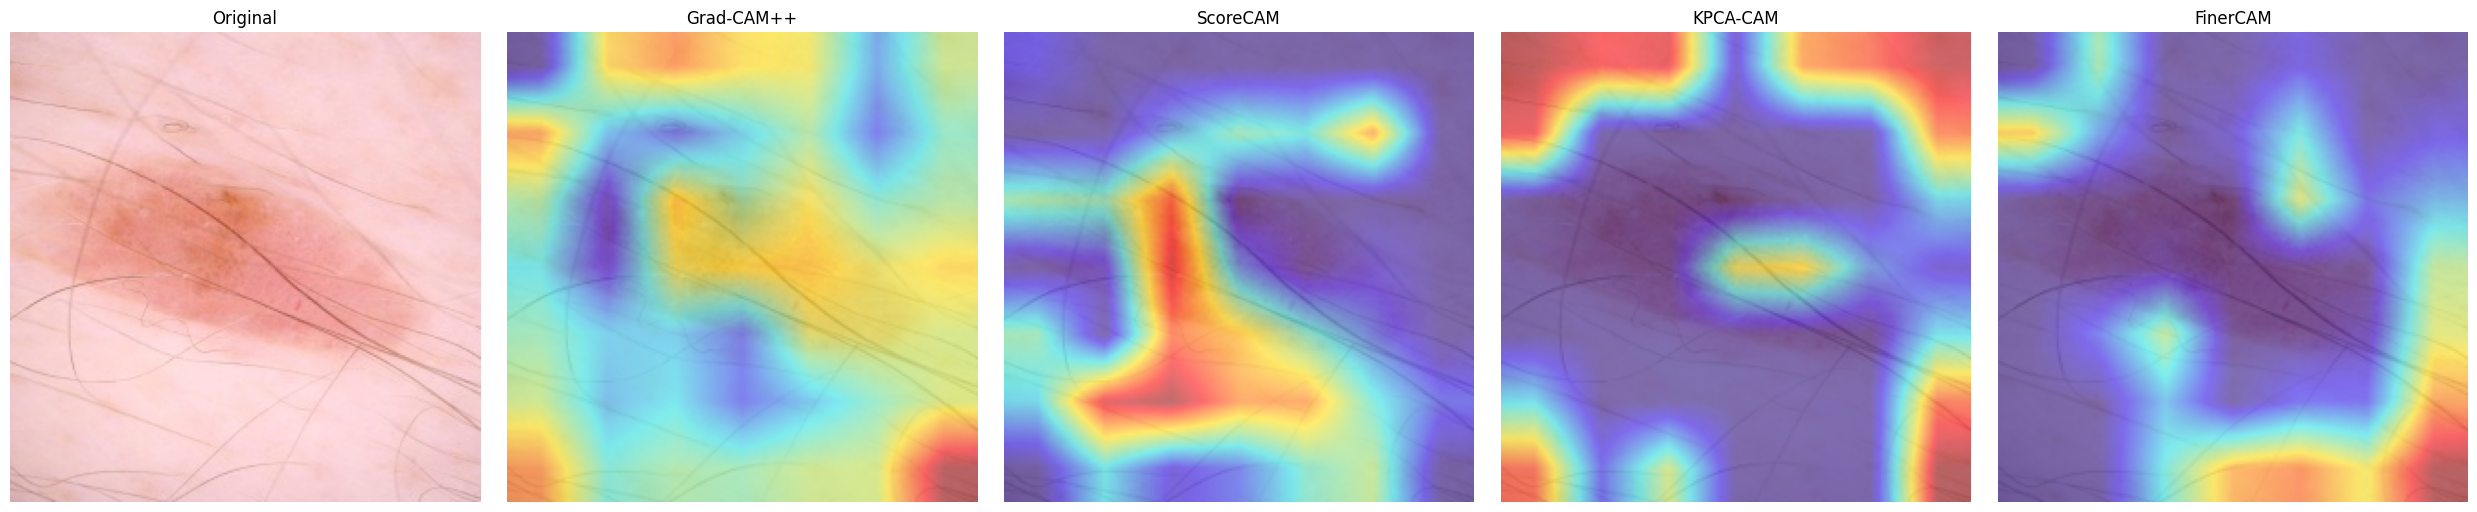

In [18]:
image_path="./data/test/ISIC_0822581.jpg"
XAI(image_path, model, transform)